        # GMIA v5灌漑設備ストックを追加したSpatial OOFモデル

        このノートブックは、旧モデルの保存済み予測CSVを読み込まず、GMIA v5の灌漑設備ストックを説明変数に追加したモデルを新たに再推定する。

        - GMIA入力：`gmia_v5_equipped_share_of_cropland_2005_wx50km.npy`
        - 定義：50 km近傍のGMIA灌漑設備面積 ÷ 50 km近傍のHYDE 2005年耕作地面積
        - GMIAは `Market access and infrastructure` に分類
        - 旧モデルは、GMIA有効セルの共通標本で比較用に再学習
        - Spatial OOF、2段階予測、各段階のTreeSHAPを新たに計算
        - 旧 `soil_comparison_oof_predictions.csv.gz` は使用しない

        実行には、最初からこのノートブックを順番に実行する。旧モデルの予測CSVを復旧する必要はない。
        

# 耕作地割合：カロリーポテンシャル限定・土壌群追加・Spatial OOF LightGBM

現地と周辺の農業ポテンシャルをカロリー指標に統一した二段階LightGBMです。
永久湿地（exclusion class 5）は推定対象から除外し、5-fold Spatial OOFで評価します。

## 分析仕様

- 現地：天水カロリーポテンシャル、灌漑によるカロリー増分
- 周辺：50 kmの天水カロリーポテンシャルのみ
- 水資源：現地GloFAS流量、一定規模以上の河川までの距離
- 土地：標高、傾斜、環境除外区分、WRB土壌群
- 市場アクセス：都市・港までの時間距離
- 除外：金額ポテンシャル、100 km農業ポテンシャル、周辺GloFAS、人口変数

## 1. 設定とライブラリ

In [1]:
from __future__ import annotations

import gc
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio

from IPython.display import display
from rasterio.enums import Resampling
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.neighbors import BallTree
from lightgbm import LGBMClassifier, LGBMRegressor

warnings.filterwarnings("ignore", category=RuntimeWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 220)

ROOT = Path(r"C:\masterresearch\Comparative_advantage")
GAEZ_DIR = ROOT / "GAEZ"
HYDE_DIR = ROOT / "HYDE3.4"
CROPLAND_DIR = HYDE_DIR / "cropland_npys"
DIST_DIR = ROOT / "distance_to_cities"
GLOFAS_DIR = ROOT / "GloFAS" / "processed_5min"
FEATURE_CACHE = GAEZ_DIR / "CroplandRegression" / "features_cache"
WX_CACHE_DIR = GAEZ_DIR / "CroplandRegression" / "spatial_wx_comparison"
LAND_MASK_DIR = GAEZ_DIR / "LandMasks"
DERIVED_MASK_DIR = LAND_MASK_DIR / "derived_5min"
OUTPUT_DIR = GAEZ_DIR / "CroplandRegression" / "soil_group_calorie_only_50km"

DERIVED_MASK_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SOIL_TIF = LAND_MASK_DIR / "gaez_v5_wrb_soil_group_30sec.tif"
EXCLUSION_TIF = LAND_MASK_DIR / "gaez_v5_exclusion_30sec.tif"
SOIL_5MIN_CACHE = DERIVED_MASK_DIR / "gaez_v5_wrb_soil_group_5min_mode.npy"
EXCLUSION_5MIN_CACHE = DERIVED_MASK_DIR / "gaez_v5_exclusion_5min_mode.npy"

YEAR = 2024
RANDOM_SEED = 42
PRESENCE_THRESHOLD = 0.01
N_POS_SAMPLE = 120_000
N_ZERO_SAMPLE = 120_000
N_SPLITS = 5
N_JOBS = 4
MORAN_K = 8
MORAN_MAX_N = 50_000
SHAP_MAX_ROWS_PER_FOLD = 10_000

for required_path in [SOIL_TIF, EXCLUSION_TIF]:
    if not required_path.exists():
        raise FileNotFoundError(required_path)

print("output:", OUTPUT_DIR)


output: C:\masterresearch\Comparative_advantage\GAEZ\CroplandRegression\soil_group_calorie_only_50km


## 2. GAEZ土壌群・環境除外区分を5分グリッドへ集約

In [2]:
lat = np.load(CROPLAND_DIR / "lat.npy")
lon = np.load(CROPLAND_DIR / "lon.npy")
shape = (len(lat), len(lon))


def load_or_build_mode_cache(source_tif, cache_path, target_shape, fill_value=-1):
    if cache_path.exists():
        cached = np.load(cache_path, mmap_mode="r")
        if cached.shape == target_shape:
            print("load mode cache:", cache_path.name)
            return cached
        print("cache shape mismatch; rebuild:", cache_path)

    print("build mode cache:", cache_path.name)
    with rasterio.open(source_tif) as src:
        print("  source shape:", (src.height, src.width))
        print("  source bounds:", src.bounds)
        print("  source nodata:", src.nodata)
        reduced = src.read(
            1,
            out_shape=target_shape,
            resampling=Resampling.mode,
            masked=True,
        )

    # uint16ラスタには-1を直接fillできないため、先に符号付き整数へ変換する。
    reduced = reduced.astype(np.int32).filled(fill_value).astype(np.int16)
    np.save(cache_path, reduced)
    print("  saved:", cache_path)
    del reduced
    gc.collect()
    return np.load(cache_path, mmap_mode="r")


soil_group = load_or_build_mode_cache(
    SOIL_TIF,
    SOIL_5MIN_CACHE,
    shape,
)
exclusion = load_or_build_mode_cache(
    EXCLUSION_TIF,
    EXCLUSION_5MIN_CACHE,
    shape,
)

print("grid shape:", shape)
print("latitude order:", float(lat[0]), "to", float(lat[-1]))
print("longitude order:", float(lon[0]), "to", float(lon[-1]))


load mode cache: gaez_v5_wrb_soil_group_5min_mode.npy
load mode cache: gaez_v5_exclusion_5min_mode.npy
grid shape: (2160, 4320)
latitude order: 89.95825958251953 to -89.95833587646484
longitude order: -179.9583282470703 to 179.95819091796875


## 3. 説明変数の読込と50 km周辺カロリー指標の作成

In [3]:
def load_cache(*names):
    for name in names:
        path = FEATURE_CACHE / name
        if path.exists():
            print("load cache:", path.name)
            return np.load(path, mmap_mode="r")
    raise FileNotFoundError("Required cache not found: " + ", ".join(names))


def safe_log1p(values):
    values = np.asarray(values, dtype=np.float32)
    values = np.where(np.isfinite(values) & (values > 0), values, 0.0)
    return np.log1p(values).astype(np.float32)


def positive_raw(values):
    values = np.asarray(values, dtype=np.float32)
    return np.where(
        np.isfinite(values) & (values > 0),
        values,
        0.0,
    ).astype(np.float32)


def _rolling_sum_horizontal(values, half_width):
    values = np.asarray(values, dtype=np.float32)
    if half_width <= 0:
        return values.copy()
    extended = np.concatenate(
        [values[:, -half_width:], values, values[:, :half_width]],
        axis=1,
    )
    width = 2 * half_width + 1
    cumulative = np.concatenate(
        [
            np.zeros((values.shape[0], 1), dtype=np.float64),
            np.cumsum(extended, axis=1, dtype=np.float64),
        ],
        axis=1,
    )
    return (cumulative[:, width:] - cumulative[:, :-width]).astype(np.float32)


def _rolling_sum_vertical(values, half_width):
    values = np.asarray(values, dtype=np.float32)
    if half_width <= 0:
        return values.copy()
    padded = np.pad(values, ((half_width, half_width), (0, 0)), mode="edge")
    width = 2 * half_width + 1
    cumulative = np.concatenate(
        [
            np.zeros((1, values.shape[1]), dtype=np.float64),
            np.cumsum(padded, axis=0, dtype=np.float64),
        ],
        axis=0,
    )
    return (cumulative[width:, :] - cumulative[:-width, :]).astype(np.float32)


def latitude_aware_box_mean(
    values,
    lat_values,
    lon_values,
    radius_km,
    min_valid_fraction=0.25,
):
    values = np.asarray(values, dtype=np.float32)
    expected_shape = (len(lat_values), len(lon_values))
    if values.shape != expected_shape:
        raise ValueError(
            f"Unexpected raster shape: {values.shape}; expected {expected_shape}"
        )

    earth_radius_km = 6371.0088
    km_per_degree = earth_radius_km * np.pi / 180.0
    lat_step_deg = float(np.median(np.abs(np.diff(lat_values))))
    lon_step_deg = float(np.median(np.abs(np.diff(lon_values))))
    half_lat = max(
        1,
        int(np.ceil(radius_km / (km_per_degree * lat_step_deg))),
    )

    cos_lat = np.clip(np.cos(np.deg2rad(lat_values)), 1e-6, None)
    half_lon_by_row = np.ceil(
        radius_km / (km_per_degree * cos_lat * lon_step_deg)
    ).astype(np.int32)
    half_lon_by_row = np.minimum(
        half_lon_by_row,
        values.shape[1] // 2 - 1,
    )

    finite = np.isfinite(values)
    filled = np.where(finite, values, 0.0).astype(np.float32)
    counts = finite.astype(np.float32)
    horizontal_sum = np.zeros_like(filled, dtype=np.float32)
    horizontal_count = np.zeros_like(counts, dtype=np.float32)

    for half_lon in np.unique(half_lon_by_row):
        row_indices = np.flatnonzero(half_lon_by_row == half_lon)
        horizontal_sum[row_indices] = _rolling_sum_horizontal(
            filled[row_indices],
            int(half_lon),
        )
        horizontal_count[row_indices] = _rolling_sum_horizontal(
            counts[row_indices],
            int(half_lon),
        )

    vertical_sum = _rolling_sum_vertical(horizontal_sum, half_lat)
    vertical_count = _rolling_sum_vertical(horizontal_count, half_lat)

    row_width = (2 * half_lon_by_row + 1).astype(np.float64)
    padded_width = np.pad(row_width, (half_lat, half_lat), mode="edge")
    cumulative_width = np.concatenate([[0.0], np.cumsum(padded_width)])
    window_width_by_row = (
        cumulative_width[2 * half_lat + 1:]
        - cumulative_width[:-(2 * half_lat + 1)]
    )
    minimum_count = min_valid_fraction * window_width_by_row

    result = np.full(values.shape, np.nan, dtype=np.float32)
    valid = vertical_count >= minimum_count[:, None]
    with np.errstate(divide="ignore", invalid="ignore"):
        result[valid] = (
            vertical_sum[valid] / vertical_count[valid]
        ).astype(np.float32)
    return result


cropland_cube = np.load(
    CROPLAND_DIR / "cropland_fraction_1950_2024.npy",
    mmap_mode="r",
)
years = np.load(CROPLAND_DIR / "years.npy")
year_index = int(np.where(years == YEAR)[0][0])
cropland = np.asarray(cropland_cube[year_index], dtype=np.float32).copy()
cropland[~np.isfinite(cropland)] = np.nan

# Population is used only to preserve the existing land/sample mask.
# It is not included as a predictor.
population = load_cache("population_density_2024.npy")
elevation = load_cache("elevation_5min.npy")
slope = load_cache("slope_5min.npy")
city_time = np.load(DIST_DIR / "cities_10_1_12deg_min.npy", mmap_mode="r")
port_time = np.load(DIST_DIR / "ports_05_1_12deg_min.npy", mmap_mode="r")
glofas = np.load(GLOFAS_DIR / "p10_discharge_max_5min_2020.npy", mmap_mode="r")
river_distance = np.load(
    GLOFAS_DIR / "distance_to_reliable_river_p10_gt_10_m3s_km_5min_2020.npy",
    mmap_mode="r",
)

rainfed_calorie = load_cache(
    "rainfed_calorie_top5_kcal_per_ha_checked_36crops.npy",
    "rainfed_calorie_top5_checked_36crops.npy",
)
irrigated_calorie = load_cache(
    "irrigated_calorie_top5_kcal_per_ha_checked_36crops.npy",
    "irrigated_calorie_top5_checked_36crops.npy",
)

WX_50KM_CALORIE_CACHE = (
    WX_CACHE_DIR / "wx_50km_rainfed_calorie_top5_raw.npy"
)
if WX_50KM_CALORIE_CACHE.exists():
    print("load calorie WX cache:", WX_50KM_CALORIE_CACHE.name)
else:
    print("build calorie WX cache:", WX_50KM_CALORIE_CACHE.name)
    calorie_source = positive_raw(rainfed_calorie)
    wx_50km_calorie_build = latitude_aware_box_mean(
        calorie_source,
        lat,
        lon,
        radius_km=50,
        min_valid_fraction=0.25,
    )
    np.save(
        WX_50KM_CALORIE_CACHE,
        wx_50km_calorie_build.astype(np.float32, copy=False),
    )
    del calorie_source, wx_50km_calorie_build
    gc.collect()

wx_50km_rainfed_calorie = np.load(
    WX_50KM_CALORIE_CACHE,
    mmap_mode="r",
)

for name, raster in {
    "cropland": cropland,
    "soil_group": soil_group,
    "exclusion": exclusion,
    "elevation": elevation,
    "slope": slope,
    "city_time": city_time,
    "port_time": port_time,
    "glofas": glofas,
    "river_distance": river_distance,
    "rainfed_calorie": rainfed_calorie,
    "irrigated_calorie": irrigated_calorie,
    "wx_50km_rainfed_calorie": wx_50km_rainfed_calorie,
}.items():
    if raster.shape != shape:
        raise ValueError(f"shape mismatch: {name} {raster.shape} != {shape}")

print("all required rasters are aligned:", shape)


load cache: population_density_2024.npy
load cache: elevation_5min.npy
load cache: slope_5min.npy
load cache: rainfed_calorie_top5_kcal_per_ha_checked_36crops.npy
load cache: irrigated_calorie_top5_kcal_per_ha_checked_36crops.npy
load calorie WX cache: wx_50km_rainfed_calorie_top5_raw.npy
all required rasters are aligned: (2160, 4320)


## 4. 分析標本、使用変数、Spatial OOF分割

In [4]:
base_land_mask = (
    np.isfinite(elevation)
    & np.isfinite(cropland)
    & np.isfinite(population)
    & (population >= 0)
)
valid_exclusion = (exclusion >= 1) & (exclusion <= 6)
permanent_wetland = exclusion == 5
valid_soil = (soil_group >= 1) & (soil_group <= 33)

land_mask = (
    base_land_mask
    & valid_exclusion
    & ~permanent_wetland
    & valid_soil
)
presence_raster = land_mask & (cropland > PRESENCE_THRESHOLD)
target_prior = float(presence_raster.sum() / land_mask.sum())

print("base land cells:", f"{int(base_land_mask.sum()):,}")
print(
    "permanent-wetland cells removed from base land:",
    f"{int((base_land_mask & permanent_wetland).sum()):,}",
)
print("final eligible cells:", f"{int(land_mask.sum()):,}")
print("population presence prior:", target_prior)

rng = np.random.default_rng(RANDOM_SEED)
positive_flat = np.flatnonzero(presence_raster.ravel())
zero_flat = np.flatnonzero((land_mask & ~presence_raster).ravel())

positive_sample = rng.choice(
    positive_flat,
    min(N_POS_SAMPLE, len(positive_flat)),
    replace=False,
)
zero_sample = rng.choice(
    zero_flat,
    min(N_ZERO_SAMPLE, len(zero_flat)),
    replace=False,
)
sample_flat = np.concatenate([positive_sample, zero_sample])
rng.shuffle(sample_flat)
rows, cols = np.unravel_index(sample_flat, shape)


def take(array):
    return np.asarray(array[rows, cols])


rainfed_calorie_sample = take(rainfed_calorie).astype(np.float32)
irrigated_calorie_sample = take(irrigated_calorie).astype(np.float32)
calorie_pair_valid = (
    np.isfinite(rainfed_calorie_sample)
    & np.isfinite(irrigated_calorie_sample)
)
irrigation_calorie_gain = np.where(
    calorie_pair_valid,
    np.maximum(irrigated_calorie_sample - rainfed_calorie_sample, 0.0),
    0.0,
).astype(np.float32)

sample = pd.DataFrame({
    "row": rows.astype(np.int32),
    "col": cols.astype(np.int32),
    "lat": lat[rows].astype(np.float32),
    "lon": lon[cols].astype(np.float32),
    "cropland_fraction": take(cropland).astype(np.float32),
    "presence": (take(cropland) > PRESENCE_THRESHOLD).astype(np.uint8),
    "elevation_m": take(elevation).astype(np.float32),
    "slope": take(slope).astype(np.float32),
    "exclusion_class": take(exclusion).astype(np.int16),
    "soil_group_class": take(soil_group).astype(np.int16),
    "log_city_time_20k_min": safe_log1p(take(city_time)),
    "log_port_time_any_min": safe_log1p(take(port_time)),
    "log_glofas_p10_2020": safe_log1p(take(glofas)),
    "log_distance_river_gt10_2020": safe_log1p(take(river_distance)),
    "rainfed_calorie_top5_raw": positive_raw(rainfed_calorie_sample),
    "irrigation_calorie_gain_top5_raw": irrigation_calorie_gain,
    "wx_50km_rainfed_calorie_top5_raw": take(
        wx_50km_rainfed_calorie
    ).astype(np.float32),
})

sample["spatial_block"] = (
    np.floor((sample["lat"] + 90) / 10).astype(int) * 36
    + np.floor((sample["lon"] + 180) / 10).astype(int)
)

BASE_FEATURES = [
    "elevation_m",
    "slope",
    "exclusion_class",
    "log_city_time_20k_min",
    "log_port_time_any_min",
    "rainfed_calorie_top5_raw",
    "irrigation_calorie_gain_top5_raw",
    "wx_50km_rainfed_calorie_top5_raw",
    "log_distance_river_gt10_2020",
    "log_glofas_p10_2020",
]
SOIL_FEATURES = BASE_FEATURES + ["soil_group_class"]

MODEL_FEATURES = {
    "no_soil_wetland_excluded": BASE_FEATURES,
    "soil_group_wetland_excluded": SOIL_FEATURES,
}
CATEGORICAL_CANDIDATES = ["exclusion_class", "soil_group_class"]

all_features = sorted(set().union(*MODEL_FEATURES.values()))
sample = (
    sample.replace([np.inf, -np.inf], np.nan)
    .dropna(subset=all_features + ["cropland_fraction", "presence"])
    .reset_index(drop=True)
)

for column in CATEGORICAL_CANDIDATES:
    sample[column] = sample[column].astype("category")

if sample["presence"].nunique() != 2:
    raise ValueError("Both presence classes are required.")
if (sample["exclusion_class"].astype(int) == 5).any():
    raise RuntimeError("Permanent wetland remains in the analysis sample.")

groups = sample["spatial_block"].to_numpy()
y_presence = sample["presence"].to_numpy(dtype=np.uint8)
splits = list(
    GroupKFold(n_splits=N_SPLITS).split(
        sample,
        y_presence,
        groups=groups,
    )
)

try:
    area_raster = np.load(CROPLAND_DIR / "grid_area_km2.npy", mmap_mode="r")
    sample_area = np.asarray(
        area_raster[
            sample["row"].to_numpy(int),
            sample["col"].to_numpy(int),
        ],
        dtype=float,
    )
    n_pos_population = int(presence_raster.sum())
    n_zero_population = int(land_mask.sum() - presence_raster.sum())
    n_pos_sample = int((y_presence == 1).sum())
    n_zero_sample = int((y_presence == 0).sum())
    area_weight = np.where(
        y_presence == 1,
        n_pos_population / max(n_pos_sample, 1),
        n_zero_population / max(n_zero_sample, 1),
    ) * sample_area
except FileNotFoundError:
    print("grid_area_km2.npy not found; area weighting is skipped.")
    area_weight = None

print("common analysis rows:", len(sample))
print("presence share in balanced sample:", sample["presence"].mean())
print("spatial blocks:", sample["spatial_block"].nunique())
for model_name, features in MODEL_FEATURES.items():
    print(f"{model_name:32s}: {len(features)} features")
print("calorie-only features:", SOIL_FEATURES)


base land cells: 2,215,635
permanent-wetland cells removed from base land: 69,237
final eligible cells: 2,100,681
population presence prior: 0.36645306926658544
common analysis rows: 240000
presence share in balanced sample: 0.5
spatial blocks: 290
no_soil_wetland_excluded        : 10 features
soil_group_wetland_excluded     : 11 features
calorie-only features: ['elevation_m', 'slope', 'exclusion_class', 'log_city_time_20k_min', 'log_port_time_any_min', 'rainfed_calorie_top5_raw', 'irrigation_calorie_gain_top5_raw', 'wx_50km_rainfed_calorie_top5_raw', 'log_distance_river_gt10_2020', 'log_glofas_p10_2020', 'soil_group_class']


## 5. 土壌群と永久湿地除外の確認

,soil_group_class,soil_group,n,share_percent
0,1,Acrisols,10984,4.577
1,2,Alisols,610,0.254
2,3,Andosols,1561,0.650
3,4,Arenosols,16032,6.680
4,5,Anthrosols,932,0.388
5,6,Chernozems,6187,2.578
6,7,Calcisols,8911,3.713
7,8,Cambisols,17969,7.487
8,9,Cryosols,23557,9.815
9,10,Fluvisols,5215,2.173


Technosol sample rows: 350
Permanent-wetland sample rows: 0


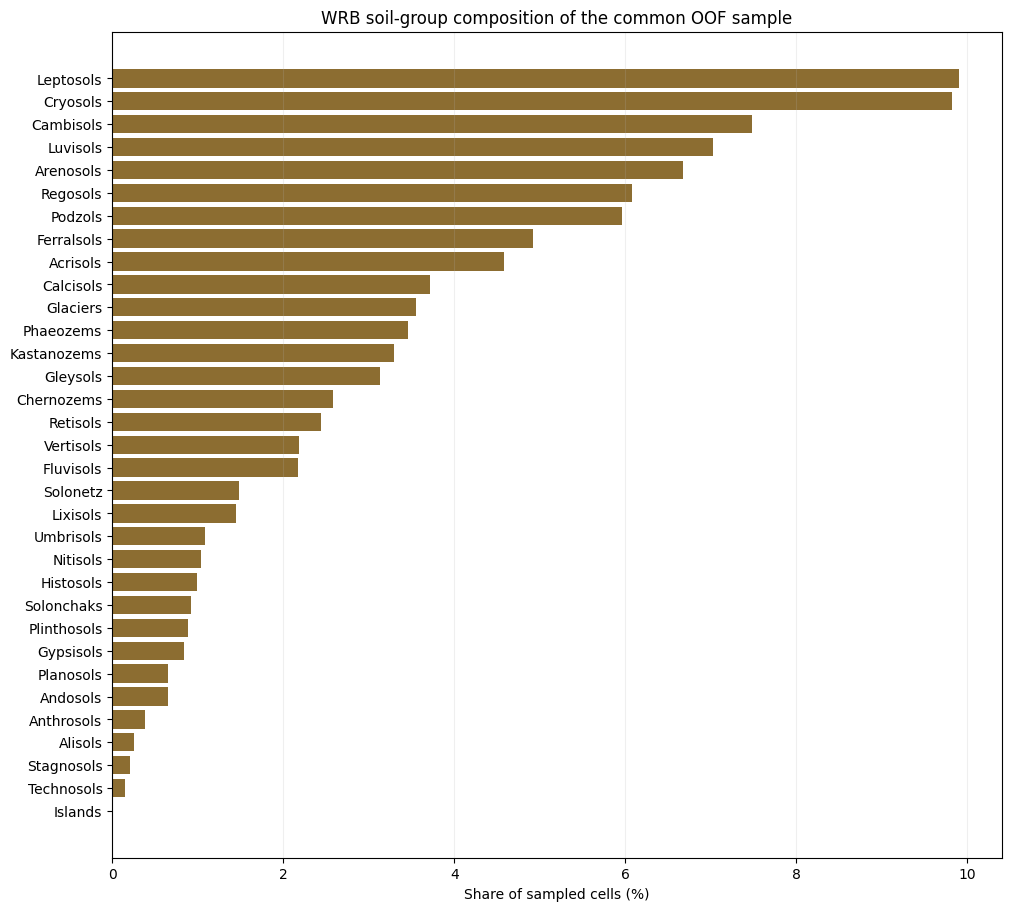

In [5]:
SOIL_LABELS = {
    1: "Acrisols", 2: "Alisols", 3: "Andosols", 4: "Arenosols",
    5: "Anthrosols", 6: "Chernozems", 7: "Calcisols", 8: "Cambisols",
    9: "Cryosols", 10: "Fluvisols", 11: "Ferralsols", 12: "Glaciers",
    13: "Gleysols", 14: "Gypsisols", 15: "Histosols", 16: "Islands",
    17: "Kastanozems", 18: "Leptosols", 19: "Luvisols", 20: "Lixisols",
    21: "Nitisols", 22: "Phaeozems", 23: "Planosols", 24: "Plinthosols",
    25: "Podzols", 26: "Regosols", 27: "Retisols", 28: "Solonchaks",
    29: "Solonetz", 30: "Stagnosols", 31: "Technosols", 32: "Umbrisols",
    33: "Vertisols", 34: "Open Water",
}

soil_codes = sample["soil_group_class"].astype(int)
soil_distribution = (
    soil_codes.value_counts()
    .sort_index()
    .rename_axis("soil_group_class")
    .reset_index(name="n")
)
soil_distribution["soil_group"] = soil_distribution["soil_group_class"].map(SOIL_LABELS)
soil_distribution["share_percent"] = 100 * soil_distribution["n"] / soil_distribution["n"].sum()
display(soil_distribution[["soil_group_class", "soil_group", "n", "share_percent"]].round(3))

technosol_n = int((soil_codes == 31).sum())
print("Technosol sample rows:", f"{technosol_n:,}")
print("Permanent-wetland sample rows:", int((sample["exclusion_class"].astype(int) == 5).sum()))

plot_frame = soil_distribution.sort_values("share_percent")
fig, ax = plt.subplots(figsize=(10, 9), constrained_layout=True)
ax.barh(
    plot_frame["soil_group"],
    plot_frame["share_percent"],
    color="#8C6D31",
)
ax.set_title("WRB soil-group composition of the common OOF sample")
ax.set_xlabel("Share of sampled cells (%)")
ax.grid(axis="x", alpha=0.2)
plt.show()


## 6. 二段階LightGBM・評価・SHAP関数

In [6]:
def adjust_probability_prior_shift(
    probability,
    sample_prior,
    population_prior,
    eps=1e-6,
):
    probability = np.clip(np.asarray(probability, dtype=float), eps, 1 - eps)
    sample_prior = float(np.clip(sample_prior, eps, 1 - eps))
    population_prior = float(np.clip(population_prior, eps, 1 - eps))
    odds = probability / (1.0 - probability)
    odds *= (
        (population_prior / (1.0 - population_prior))
        / (sample_prior / (1.0 - sample_prior))
    )
    return odds / (1.0 + odds)


def regression_metrics(y_true, y_pred, weights=None):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    valid = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[valid]
    y_pred = y_pred[valid]

    if weights is None:
        weights = np.ones(len(y_true), dtype=float)
    else:
        weights = np.asarray(weights, dtype=float)[valid]

    residual = y_true - y_pred
    observed_mean = np.average(y_true, weights=weights)
    ss_res = np.sum(weights * residual ** 2)
    ss_tot = np.sum(weights * (y_true - observed_mean) ** 2)

    return {
        "n": int(len(y_true)),
        "observed_mean": float(observed_mean),
        "predicted_mean": float(np.average(y_pred, weights=weights)),
        "r2": float(1.0 - ss_res / ss_tot) if ss_tot > 0 else np.nan,
        "rmse": float(np.sqrt(np.average(residual ** 2, weights=weights))),
        "mae": float(np.average(np.abs(residual), weights=weights)),
        "bias_observed_minus_predicted": float(np.average(residual, weights=weights)),
    }


def categorical_features_for(features):
    return [
        feature
        for feature in CATEGORICAL_CANDIDATES
        if feature in features
    ]


def fit_models(train_df, features, fold_number):
    categorical_features = categorical_features_for(features)

    classifier = LGBMClassifier(
        objective="binary",
        n_estimators=450,
        learning_rate=0.035,
        num_leaves=31,
        min_child_samples=80,
        subsample=0.85,
        colsample_bytree=0.85,
        random_state=RANDOM_SEED + fold_number,
        n_jobs=N_JOBS,
        verbose=-1,
    )
    classifier.fit(
        train_df[features],
        train_df["presence"],
        categorical_feature=categorical_features,
    )

    positive_train = train_df[train_df["presence"].eq(1)]
    regressor = LGBMRegressor(
        objective="regression",
        n_estimators=550,
        learning_rate=0.03,
        num_leaves=31,
        min_child_samples=60,
        subsample=0.85,
        colsample_bytree=0.85,
        random_state=RANDOM_SEED + fold_number,
        n_jobs=N_JOBS,
        verbose=-1,
    )
    regressor.fit(
        positive_train[features],
        positive_train["cropland_fraction"],
        categorical_feature=categorical_features,
    )
    return classifier, regressor


def extract_tree_shap(explainer, values):
    shap_values = explainer.shap_values(values)
    if isinstance(shap_values, list):
        shap_values = shap_values[-1]
    shap_values = np.asarray(shap_values)
    if shap_values.ndim == 3:
        shap_values = shap_values[:, :, -1]
    if shap_values.ndim != 2:
        raise ValueError(f"Unexpected SHAP shape: {shap_values.shape}")
    return shap_values


def select_local_positions(n_rows, max_rows, seed):
    if n_rows <= max_rows:
        return np.arange(n_rows, dtype=int)
    local_rng = np.random.default_rng(seed)
    return np.sort(
        local_rng.choice(n_rows, max_rows, replace=False)
    )


def add_shap_summaries(
    output_rows,
    model_name,
    stage,
    fold_number,
    features,
    shap_values,
    weights,
):
    weights = np.asarray(weights, dtype=float)
    valid_weight = np.isfinite(weights) & (weights > 0)
    if not valid_weight.any():
        weights = np.ones(len(shap_values), dtype=float)
        valid_weight = np.ones(len(shap_values), dtype=bool)

    shap_values = shap_values[valid_weight]
    weights = weights[valid_weight]
    for feature_index, feature in enumerate(features):
        values = shap_values[:, feature_index]
        output_rows.append({
            "model": model_name,
            "stage": stage,
            "fold": fold_number,
            "feature": feature,
            "sum_weight": float(weights.sum()),
            "sum_abs_shap_weighted": float(np.sum(weights * np.abs(values))),
            "sum_signed_shap_weighted": float(np.sum(weights * values)),
            "n": int(len(values)),
        })


## 7. 5-fold Spatial OOFと全説明変数のローカルSHAP

## 22. GMIA v5灌漑設備ストックを追加した新規OOFモデル

ここからは、旧モデルの保存済み予測ファイルを読み込まず、GMIA v5の灌漑設備ストック変数を追加したモデルをSpatial OOFで新たに再推定する。旧モデルは、GMIAが有効な共通標本上で比較するためだけに同じ条件で再推定する。

追加変数：

`gmia_v5_equipped_share_of_cropland_2005_wx50km`

これは、50 km近傍のGMIA設備面積を、50 km近傍のHYDE 2005年耕作地面積で割った変数である。GMIAの「設備面積 / セル面積」は耕作地量を含み得るため、モデル投入には使用せず、診断用に限定する。

このセクションでは、GMIA変数が有効なセルだけで共通標本を作り、次の2モデルを保存済み旧予測に依存せず再推定する。

1. 既存の `soil_group_wetland_excluded`
2. `soil_group_wetland_excluded + GMIA`

既存の2段階構造、Spatial OOF、面積加重、各段階のTreeSHAPを同じ条件で維持する。GMIA追加モデルのOOF予測とSHAPは新たに計算する。

c:\Users\tsuda\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded GMIA feature: C:\masterresearch\Comparative_advantage\GAEZ\CroplandRegression\features_cache\gmia_v5_equipped_share_of_cropland_2005_wx50km.npy
GMIA feature shape: (2160, 4320)
Original analysis rows: 240000
GMIA-complete analysis rows: 161959
GMIA-complete positive rows: 119782
GMIA-complete zero rows: 42177
GMIA comparison models:
  soil_group_wetland_excluded: 11 features
  soil_group_gmia_wetland_excluded: 12 features
GMIA MODEL 1/2: soil_group_wetland_excluded (11 features)
  fold 1/5


c:\Users\tsuda\AppData\Local\Programs\Python\Python313\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


  fold 2/5


c:\Users\tsuda\AppData\Local\Programs\Python\Python313\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


...

c:\Users\tsuda\AppData\Local\Programs\Python\Python313\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


  fold 5/5


c:\Users\tsuda\AppData\Local\Programs\Python\Python313\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


Saved: C:\masterresearch\Comparative_advantage\GAEZ\CroplandRegression\soil_group_calorie_only_50km\gmia_added\gmia_model_comparison_oof_predictions.csv.gz
Saved: C:\masterresearch\Comparative_advantage\GAEZ\CroplandRegression\soil_group_calorie_only_50km\gmia_added\gmia_model_oof_local_feature_shap.csv.gz
GMIA model comparison completed.


,model,weighting,n_features,n,r2,rmse,mae,bias_observed_minus_predicted,observed_mean,predicted_mean
0,soil_group_wetland_excluded,unweighted_common_sample,11,161959,0.470623,0.177411,0.115532,0.047499,0.207896,0.160397
1,soil_group_wetland_excluded,area_weighted_reweighted,11,161959,0.536291,0.136427,0.074324,0.008349,0.103431,0.095082
2,soil_group_gmia_wetland_excluded,unweighted_common_sample,12,161959,0.490628,0.174026,0.112989,0.046178,0.207896,0.161718
3,soil_group_gmia_wetland_excluded,area_weighted_reweighted,12,161959,0.556391,0.133437,0.071941,0.008704,0.103431,0.094726


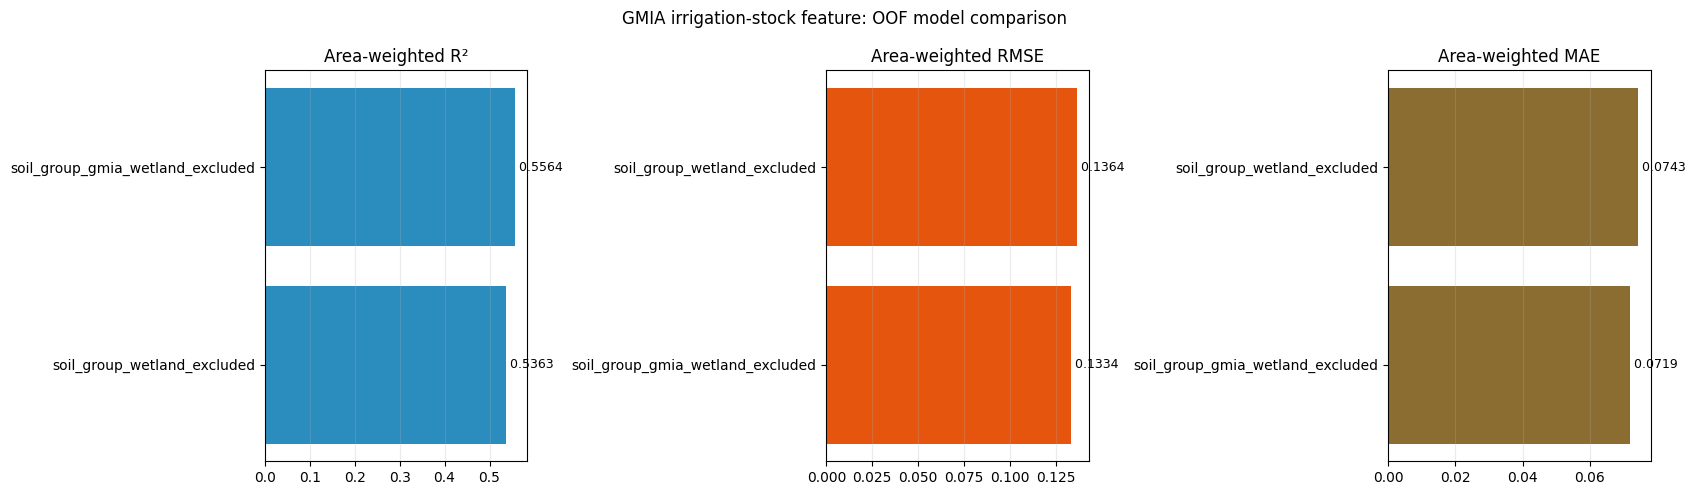

Saved: C:\masterresearch\Comparative_advantage\GAEZ\CroplandRegression\soil_group_calorie_only_50km\gmia_added\gmia_model_comparison_metrics.png


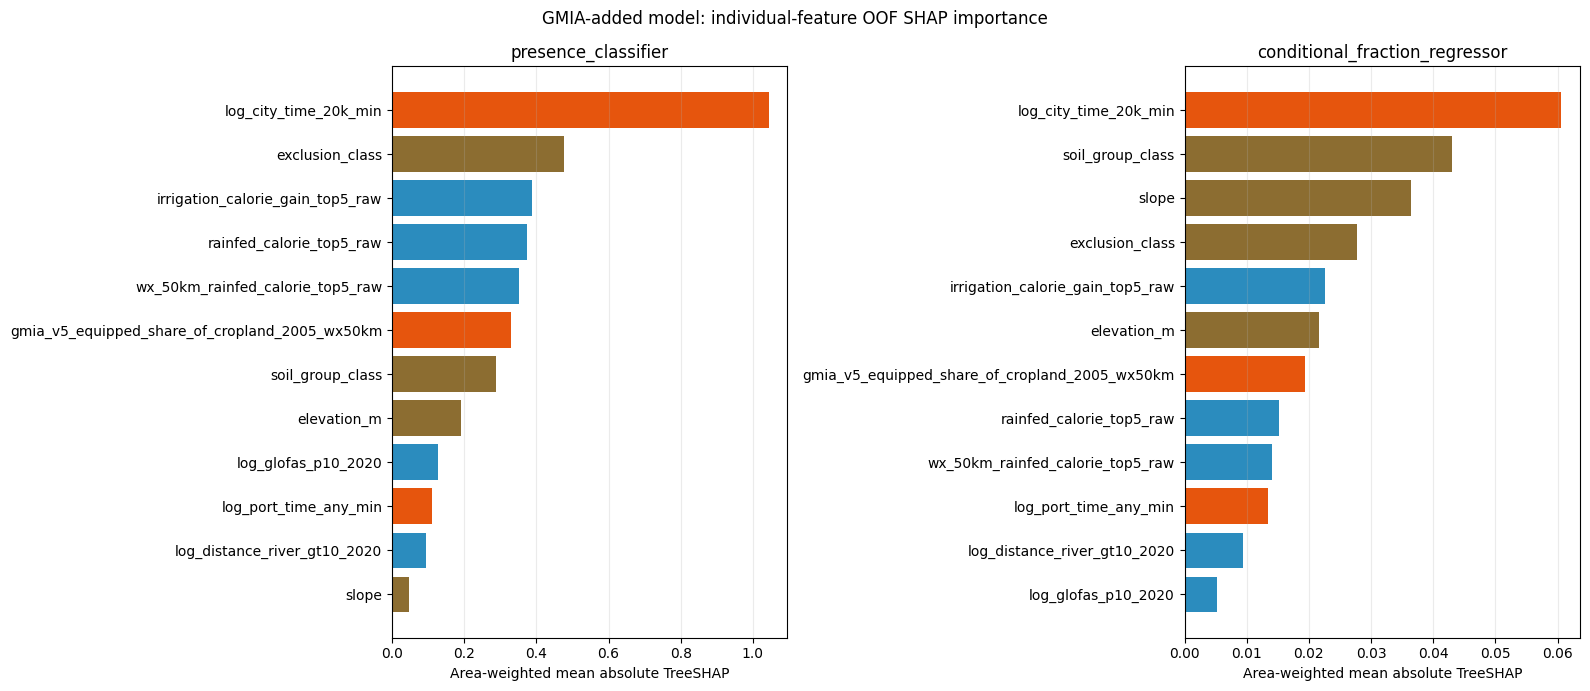

Saved: C:\masterresearch\Comparative_advantage\GAEZ\CroplandRegression\soil_group_calorie_only_50km\gmia_added\gmia_model_oof_shap_importance.png
Saved outputs:
 - C:\masterresearch\Comparative_advantage\GAEZ\CroplandRegression\soil_group_calorie_only_50km\gmia_added\gmia_model_comparison_fold_metrics.csv
 - C:\masterresearch\Comparative_advantage\GAEZ\CroplandRegression\soil_group_calorie_only_50km\gmia_added\gmia_model_comparison_global_metrics.csv
 - C:\masterresearch\Comparative_advantage\GAEZ\CroplandRegression\soil_group_calorie_only_50km\gmia_added\gmia_model_comparison_oof_predictions.csv.gz
 - C:\masterresearch\Comparative_advantage\GAEZ\CroplandRegression\soil_group_calorie_only_50km\gmia_added\gmia_model_oof_shap_summary.csv
 - C:\masterresearch\Comparative_advantage\GAEZ\CroplandRegression\soil_group_calorie_only_50km\gmia_added\gmia_model_oof_local_feature_shap.csv.gz
 - C:\masterresearch\Comparative_advantage\GAEZ\CroplandRegression\soil_group_calorie_only_50km\gmia_added

In [7]:
# ============================================================
# GMIA v5を追加した比較モデル：Spatial OOF・評価・TreeSHAP
# ============================================================

from pathlib import Path
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score, average_precision_score


# ------------------------------------------------------------
# 1. GMIA変数を読み込む
# ------------------------------------------------------------

GMIA_FEATURE_NAME = "gmia_v5_equipped_share_of_cropland_2005_wx50km"
GMIA_FEATURE_PATH = (
    FEATURE_CACHE / f"{GMIA_FEATURE_NAME}.npy"
)

if not GMIA_FEATURE_PATH.exists():
    raise FileNotFoundError(
        "GMIAモデル投入用ファイルが見つかりません: "
        f"{GMIA_FEATURE_PATH}\n"
        "先にGMIA専用ノートブックで変数を作成してください。"
    )

gmia_full = np.load(GMIA_FEATURE_PATH, mmap_mode="r")

if gmia_full.shape != shape:
    raise ValueError(
        f"GMIA変数のshapeが既存グリッドと一致しません: "
        f"{gmia_full.shape} != {shape}"
    )

print("Loaded GMIA feature:", GMIA_FEATURE_PATH)
print("GMIA feature shape:", gmia_full.shape)


# ------------------------------------------------------------
# 2. GMIA有効セルによる共通分析標本
# ------------------------------------------------------------

sample_gmia = sample.copy()
gmia_sample_values = np.asarray(
    gmia_full[
        sample_gmia["row"].to_numpy(dtype=int),
        sample_gmia["col"].to_numpy(dtype=int),
    ],
    dtype=np.float32,
)
sample_gmia[GMIA_FEATURE_NAME] = gmia_sample_values

sample_gmia = (
    sample_gmia
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=[GMIA_FEATURE_NAME])
    .reset_index(drop=True)
)

if sample_gmia["presence"].nunique() != 2:
    raise ValueError("GMIA有効標本にpresenceの2クラスがありません。")

for column in ["exclusion_class", "soil_group_class"]:
    if column in sample_gmia.columns:
        sample_gmia[column] = sample_gmia[column].astype("category")

groups_gmia = sample_gmia["spatial_block"].to_numpy()
y_presence_gmia = sample_gmia["presence"].to_numpy(dtype=np.uint8)
splits_gmia = list(
    GroupKFold(n_splits=N_SPLITS).split(
        sample_gmia,
        y_presence_gmia,
        groups=groups_gmia,
    )
)

grid_area_gmia = np.asarray(
    np.load(CROPLAND_DIR / "grid_area_km2.npy", mmap_mode="r"),
    dtype=float,
)
sample_area_gmia = grid_area_gmia[
    sample_gmia["row"].to_numpy(dtype=int),
    sample_gmia["col"].to_numpy(dtype=int),
]

n_pos_sample_gmia = int((y_presence_gmia == 1).sum())
n_zero_sample_gmia = int((y_presence_gmia == 0).sum())
n_pos_population_gmia = int(presence_raster.sum())
n_zero_population_gmia = int(land_mask.sum() - presence_raster.sum())

area_weight_gmia = np.where(
    y_presence_gmia == 1,
    n_pos_population_gmia / max(n_pos_sample_gmia, 1),
    n_zero_population_gmia / max(n_zero_sample_gmia, 1),
) * sample_area_gmia

print("Original analysis rows:", len(sample))
print("GMIA-complete analysis rows:", len(sample_gmia))
print("GMIA-complete positive rows:", n_pos_sample_gmia)
print("GMIA-complete zero rows:", n_zero_sample_gmia)


# ------------------------------------------------------------
# 3. 比較モデルの説明変数
# ------------------------------------------------------------

GMIA_SOIL_FEATURES = SOIL_FEATURES + [GMIA_FEATURE_NAME]

GMIA_COMPARISON_FEATURES = {
    "soil_group_wetland_excluded": list(SOIL_FEATURES),
    "soil_group_gmia_wetland_excluded": GMIA_SOIL_FEATURES,
}

print("GMIA comparison models:")
for model_name, features in GMIA_COMPARISON_FEATURES.items():
    print(f"  {model_name}: {len(features)} features")


# ------------------------------------------------------------
# 4. ローカルTreeSHAP保存用の補助関数
# ------------------------------------------------------------

def gmia_make_local_shap_frame(
    model_name,
    stage,
    fold_number,
    source_frame,
    features,
    shap_values,
    weights,
):
    result = source_frame[
        ["row", "col", "lat", "lon"] + list(features)
    ].reset_index(drop=True).copy()

    for feature in ["exclusion_class", "soil_group_class"]:
        if feature in result.columns:
            result[feature] = result[feature].astype(int)

    for feature_index, feature in enumerate(features):
        result[f"shap__{feature}"] = np.asarray(
            shap_values[:, feature_index],
            dtype=np.float32,
        )

    result.insert(0, "model", model_name)
    result.insert(1, "stage", stage)
    result.insert(2, "fold", fold_number)
    result["weight"] = np.asarray(weights, dtype=float)
    return result


def gmia_extract_tree_shap(model, frame):
    values = shap.TreeExplainer(model).shap_values(frame)
    if isinstance(values, list):
        values = values[-1]
    values = np.asarray(values)
    if values.ndim == 3:
        values = values[:, :, -1]
    if values.ndim != 2:
        raise ValueError(f"Unexpected SHAP shape: {values.shape}")
    return values


def gmia_select_positions(n_rows, max_rows, seed):
    if n_rows <= max_rows:
        return np.arange(n_rows, dtype=int)
    local_rng = np.random.default_rng(seed)
    return np.sort(
        local_rng.choice(n_rows, max_rows, replace=False)
    )


def gmia_weighted_metrics(y_true, y_pred, weights=None):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    valid = np.isfinite(y_true) & np.isfinite(y_pred)

    y_true = y_true[valid]
    y_pred = y_pred[valid]

    if weights is None:
        weights = np.ones(len(y_true), dtype=float)
    else:
        weights = np.asarray(weights, dtype=float)[valid]

    observed_mean = np.average(y_true, weights=weights)
    residual = y_true - y_pred
    ss_res = np.sum(weights * residual**2)
    ss_tot = np.sum(weights * (y_true - observed_mean) ** 2)

    return {
        "n": int(len(y_true)),
        "r2": float(1.0 - ss_res / ss_tot) if ss_tot > 0 else np.nan,
        "rmse": float(np.sqrt(np.average(residual**2, weights=weights))),
        "mae": float(np.average(np.abs(residual), weights=weights)),
        "bias_observed_minus_predicted": float(
            np.average(residual, weights=weights)
        ),
        "observed_mean": float(observed_mean),
        "predicted_mean": float(np.average(y_pred, weights=weights)),
    }


# ------------------------------------------------------------
# 5. 同じSpatial OOF条件で再学習・評価・SHAP
# ------------------------------------------------------------

gmia_predictions = {}
gmia_fold_rows = []
gmia_shap_rows = []
gmia_local_rows = []
observed_gmia = sample_gmia["cropland_fraction"].to_numpy(dtype=float)

for model_number, (model_name, features) in enumerate(
    GMIA_COMPARISON_FEATURES.items(),
    start=1,
):
    print("=" * 80)
    print(
        f"GMIA MODEL {model_number}/{len(GMIA_COMPARISON_FEATURES)}: "
        f"{model_name} ({len(features)} features)"
    )
    print("=" * 80)

    expected_oof = np.full(len(sample_gmia), np.nan, dtype=np.float32)

    for fold_number, (train_idx, test_idx) in enumerate(
        splits_gmia,
        start=1,
    ):
        print(f"  fold {fold_number}/{N_SPLITS}")

        train_df = sample_gmia.iloc[train_idx]
        test_df = sample_gmia.iloc[test_idx]

        classifier, regressor = fit_models(
            train_df,
            features,
            fold_number,
        )

        raw_probability = classifier.predict_proba(
            test_df[features]
        )[:, 1]
        calibrated_probability = adjust_probability_prior_shift(
            raw_probability,
            float(train_df["presence"].mean()),
            target_prior,
        )
        conditional_fraction = np.clip(
            regressor.predict(test_df[features]),
            0.0,
            1.0,
        )
        expected_fraction = calibrated_probability * conditional_fraction
        expected_oof[test_idx] = expected_fraction.astype(np.float32)

        y_test_presence = test_df["presence"].to_numpy(dtype=np.uint8)
        y_test_fraction = test_df["cropland_fraction"].to_numpy(dtype=float)
        positive_test = y_test_presence == 1

        combined = gmia_weighted_metrics(
            y_test_fraction,
            expected_fraction,
        )
        conditional = gmia_weighted_metrics(
            y_test_fraction[positive_test],
            conditional_fraction[positive_test],
        )

        gmia_fold_rows.append({
            "model": model_name,
            "fold": fold_number,
            "n_features": len(features),
            "combined_r2": combined["r2"],
            "combined_rmse": combined["rmse"],
            "combined_mae": combined["mae"],
            "conditional_r2": conditional["r2"],
            "conditional_rmse": conditional["rmse"],
            "presence_auc": float(
                roc_auc_score(y_test_presence, raw_probability)
            ),
            "presence_average_precision": float(
                average_precision_score(y_test_presence, raw_probability)
            ),
        })

        # Stage 1: 全テストセル
        selected_presence = gmia_select_positions(
            len(test_df),
            SHAP_MAX_ROWS_PER_FOLD,
            RANDOM_SEED + 11000 + fold_number,
        )
        presence_frame = test_df.iloc[selected_presence]
        presence_global_idx = test_idx[selected_presence]
        presence_values = gmia_extract_tree_shap(
            classifier,
            presence_frame[features],
        )
        presence_weights = area_weight_gmia[presence_global_idx]

        for feature_index, feature in enumerate(features):
            shap_feature_values = presence_values[:, feature_index]
            gmia_shap_rows.append({
                "model": model_name,
                "stage": "presence_classifier",
                "fold": fold_number,
                "feature": feature,
                "sum_weight": float(presence_weights.sum()),
                "sum_abs_shap_weighted": float(
                    np.sum(presence_weights * np.abs(shap_feature_values))
                ),
                "sum_signed_shap_weighted": float(
                    np.sum(presence_weights * shap_feature_values)
                ),
                "n": int(len(shap_feature_values)),
            })

        gmia_local_rows.append(
            gmia_make_local_shap_frame(
                model_name,
                "presence_classifier",
                fold_number,
                presence_frame,
                features,
                presence_values,
                presence_weights,
            )
        )

        # Stage 2: cropland-positiveテストセルのみ
        positive_positions = np.flatnonzero(positive_test)
        selected_positive_positions = gmia_select_positions(
            len(positive_positions),
            SHAP_MAX_ROWS_PER_FOLD,
            RANDOM_SEED + 12000 + fold_number,
        )
        selected_positive = positive_positions[selected_positive_positions]
        fraction_frame = test_df.iloc[selected_positive]
        fraction_global_idx = test_idx[selected_positive]
        fraction_values = gmia_extract_tree_shap(
            regressor,
            fraction_frame[features],
        )
        fraction_weights = area_weight_gmia[fraction_global_idx]

        for feature_index, feature in enumerate(features):
            shap_feature_values = fraction_values[:, feature_index]
            gmia_shap_rows.append({
                "model": model_name,
                "stage": "conditional_fraction_regressor",
                "fold": fold_number,
                "feature": feature,
                "sum_weight": float(fraction_weights.sum()),
                "sum_abs_shap_weighted": float(
                    np.sum(fraction_weights * np.abs(shap_feature_values))
                ),
                "sum_signed_shap_weighted": float(
                    np.sum(fraction_weights * shap_feature_values)
                ),
                "n": int(len(shap_feature_values)),
            })

        gmia_local_rows.append(
            gmia_make_local_shap_frame(
                model_name,
                "conditional_fraction_regressor",
                fold_number,
                fraction_frame,
                features,
                fraction_values,
                fraction_weights,
            )
        )

        del classifier, regressor
        del raw_probability, calibrated_probability
        del conditional_fraction, expected_fraction
        gc.collect()

    if not np.isfinite(expected_oof).all():
        raise RuntimeError(
            f"GMIAモデルのOOF予測が未完成です: {model_name}"
        )

    gmia_predictions[model_name] = expected_oof


# ------------------------------------------------------------
# 6. 結果表の作成・保存
# ------------------------------------------------------------

gmia_fold_metrics = pd.DataFrame(gmia_fold_rows)
gmia_shap_summary = pd.DataFrame(gmia_shap_rows)
gmia_local_feature_shap = pd.concat(
    gmia_local_rows,
    ignore_index=True,
)

gmia_global_rows = []
for model_name, prediction in gmia_predictions.items():
    for weighting, weights in {
        "unweighted_common_sample": None,
        "area_weighted_reweighted": area_weight_gmia,
    }.items():
        gmia_global_rows.append({
            "model": model_name,
            "weighting": weighting,
            "n_features": len(GMIA_COMPARISON_FEATURES[model_name]),
            **gmia_weighted_metrics(
                observed_gmia,
                prediction,
                weights=weights,
            ),
        })

gmia_global_metrics = pd.DataFrame(gmia_global_rows)

gmia_prediction_table = sample_gmia[
    [
        "row", "col", "lat", "lon", "spatial_block",
        "presence", "cropland_fraction", "exclusion_class",
        "soil_group_class", GMIA_FEATURE_NAME,
    ]
].copy()

for model_name, prediction in gmia_predictions.items():
    gmia_prediction_table[f"pred_{model_name}"] = prediction

GMIA_OUTPUT_DIR = OUTPUT_DIR / "gmia_added"
GMIA_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
gmia_output_dir = GMIA_OUTPUT_DIR


def gmia_save_csv_atomic(frame, path, compression=None):
    """途中停止で壊れたCSVを残さないため、一時保存後に置換する。"""
    path = Path(path)
    temp_path = path.with_name(path.name + ".tmp")

    frame.to_csv(
        temp_path,
        index=False,
        compression=compression,
    )

    if compression == "gzip":
        import gzip
        with gzip.open(temp_path, "rb") as stream:
            while stream.read(1024 * 1024):
                pass

    temp_path.replace(path)
    print("Saved:", path)

gmia_fold_metrics.to_csv(
    gmia_output_dir / "gmia_model_comparison_fold_metrics.csv",
    index=False,
    encoding="utf-8-sig",
)
gmia_global_metrics.to_csv(
    gmia_output_dir / "gmia_model_comparison_global_metrics.csv",
    index=False,
    encoding="utf-8-sig",
)
gmia_save_csv_atomic(
    gmia_prediction_table,
    gmia_output_dir / "gmia_model_comparison_oof_predictions.csv.gz",
    compression="gzip",
)
gmia_shap_summary.to_csv(
    gmia_output_dir / "gmia_model_oof_shap_summary.csv",
    index=False,
    encoding="utf-8-sig",
)
gmia_save_csv_atomic(
    gmia_local_feature_shap,
    gmia_output_dir / "gmia_model_oof_local_feature_shap.csv.gz",
    compression="gzip",
)

print("GMIA model comparison completed.")
display(gmia_global_metrics.round(6))


# ------------------------------------------------------------
# 7. R²・誤差・GMIA追加モデルのSHAP可視化
# ------------------------------------------------------------

area_metrics = gmia_global_metrics[
    gmia_global_metrics["weighting"] == "area_weighted_reweighted"
].copy()

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

metric_specs = [
    ("r2", "Area-weighted R²", "#2B8CBE"),
    ("rmse", "Area-weighted RMSE", "#E6550D"),
    ("mae", "Area-weighted MAE", "#8C6D31"),
]

for ax, (metric, title, color) in zip(axes, metric_specs):
    plot_data = area_metrics.sort_values(metric)
    ax.barh(plot_data["model"], plot_data[metric], color=color)
    ax.set_title(title)
    ax.grid(axis="x", alpha=0.25)
    for y_position, value in enumerate(plot_data[metric]):
        ax.text(
            value,
            y_position,
            f" {value:.4f}",
            va="center",
            fontsize=9,
        )

fig.suptitle("GMIA irrigation-stock feature: OOF model comparison")
fig.tight_layout()
gmia_metrics_figure = gmia_output_dir / "gmia_model_comparison_metrics.png"
fig.savefig(gmia_metrics_figure, dpi=180, bbox_inches="tight")
plt.show()
print("Saved:", gmia_metrics_figure)


gmia_shap_summary = gmia_shap_summary.assign(
    mean_abs_shap=lambda frame: (
        frame["sum_abs_shap_weighted"] / frame["sum_weight"]
    ),
    mean_signed_shap=lambda frame: (
        frame["sum_signed_shap_weighted"] / frame["sum_weight"]
    ),
)

gmia_only_shap = gmia_shap_summary[
    gmia_shap_summary["model"] == "soil_group_gmia_wetland_excluded"
].copy()

factor_colors = {
    "Market access and infrastructure": "#E6550D",
    "Climate and water capital": "#2B8CBE",
    "Land and soil capital": "#8C6D31",
}

gmia_factor_map = {
    "log_city_time_20k_min": "Market access and infrastructure",
    "log_port_time_any_min": "Market access and infrastructure",
    "gmia_v5_equipped_share_of_cropland_2005_wx50km": (
        "Market access and infrastructure"
    ),
    "elevation_m": "Land and soil capital",
    "slope": "Land and soil capital",
    "exclusion_class": "Land and soil capital",
    "soil_group_class": "Land and soil capital",
    "log_glofas_p10_2020": "Climate and water capital",
    "log_distance_river_gt10_2020": "Climate and water capital",
    "rainfed_calorie_top5_raw": "Climate and water capital",
    "irrigation_calorie_gain_top5_raw": "Climate and water capital",
    "wx_50km_rainfed_calorie_top5_raw": "Climate and water capital",
}

gmia_only_shap["factor_group"] = gmia_only_shap["feature"].map(
    gmia_factor_map
).fillna("Unclassified")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, stage in zip(
    axes,
    ["presence_classifier", "conditional_fraction_regressor"],
):
    plot_data = (
        gmia_only_shap[gmia_only_shap["stage"] == stage]
        .groupby("feature", as_index=False)["mean_abs_shap"]
        .mean()
        .sort_values("mean_abs_shap")
    )
    plot_data["factor_group"] = plot_data["feature"].map(
        gmia_factor_map
    ).fillna("Unclassified")
    colors = [
        factor_colors.get(group, "#999999")
        for group in plot_data["factor_group"]
    ]
    ax.barh(plot_data["feature"], plot_data["mean_abs_shap"], color=colors)
    ax.set_title(stage)
    ax.set_xlabel("Area-weighted mean absolute TreeSHAP")
    ax.grid(axis="x", alpha=0.25)

fig.suptitle(
    "GMIA-added model: individual-feature OOF SHAP importance"
)
fig.tight_layout()
gmia_shap_figure = gmia_output_dir / "gmia_model_oof_shap_importance.png"
fig.savefig(gmia_shap_figure, dpi=180, bbox_inches="tight")
plt.show()
print("Saved:", gmia_shap_figure)


print("Saved outputs:")
for path in [
    gmia_output_dir / "gmia_model_comparison_fold_metrics.csv",
    gmia_output_dir / "gmia_model_comparison_global_metrics.csv",
    gmia_output_dir / "gmia_model_comparison_oof_predictions.csv.gz",
    gmia_output_dir / "gmia_model_oof_shap_summary.csv",
    gmia_output_dir / "gmia_model_oof_local_feature_shap.csv.gz",
    gmia_metrics_figure,
    gmia_shap_figure,
]:
    print(" -", path)

        ## GMIA追加モデル：最終cropland fractionの統合Shapley

        GMIA追加モデルを各foldで再学習し、最終予測 `p(X)×q(X)` に対する生産要素グループ別の統合Shapleyを計算する。旧モデルの保存済み予測CSVは使用しない。背景抽出回数は32回。
        

Final model: soil_group_gmia_wetland_excluded
Features: 12
Factor groups: ['Land and soil capital', 'Climate and water capital', 'Market access and infrastructure']
Coalitions: 8
INTEGRATED FINAL SHAPLEY: fold 1/5
  background draw 1/32
  background draw 2/32
  background draw 3/32
  background draw 4/32
  background draw 5/32
  background draw 6/32
  background draw 7/32
  background draw 8/32
  background draw 9/32
  background draw 10/32
  background draw 11/32
  background draw 12/32
  background draw 13/32
  background draw 14/32
  background draw 15/32
  background draw 16/32
  background draw 17/32
  background draw 18/32
  background draw 19/32
  background draw 20/32
  background draw 21/32
  background draw 22/32
  background draw 23/32
  background draw 24/32
  background draw 25/32
  background draw 26/32
  background draw 27/32
  background draw 28/32
  background draw 29/32
  background draw 30/32
  background draw 31/32
  background draw 32/32
  maximum Shapley reconstru

,group,mean_abs_final_shap,mean_signed_final_shap,importance_share_pct
0,Market access and infrastructure,0.056219,-0.001663,41.692980
1,Land and soil capital,0.042699,-0.001396,31.666403
2,Climate and water capital,0.035922,-0.001331,26.640617



FOLD STABILITY: IMPORTANCE SHARE (%)


group,Climate and water capital,Land and soil capital,Market access and infrastructure
fold,,,
1,26.28,31.00,42.73
2,26.14,32.24,41.61
3,26.34,31.22,42.44
4,27.40,30.30,42.30
5,27.20,33.73,39.07


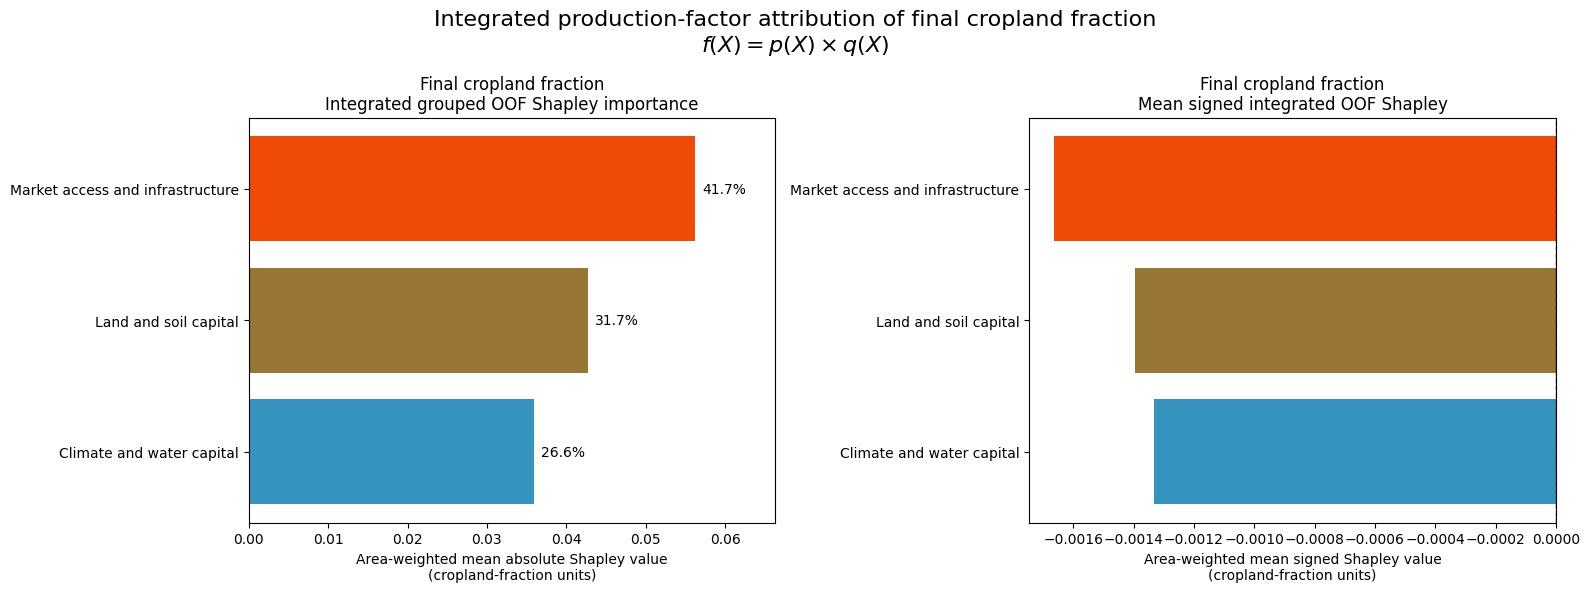


Saved:
C:\masterresearch\Comparative_advantage\GAEZ\CroplandRegression\soil_group_calorie_only_50km\gmia_added\integrated_final_cropland_group_shap_local.csv.gz
C:\masterresearch\Comparative_advantage\GAEZ\CroplandRegression\soil_group_calorie_only_50km\gmia_added\integrated_final_cropland_group_shap_by_fold.csv
C:\masterresearch\Comparative_advantage\GAEZ\CroplandRegression\soil_group_calorie_only_50km\gmia_added\integrated_final_cropland_group_shap_global.csv


In [8]:
# ============================================================
# 14. 最終cropland fraction p(X)q(X) の統合グループShapley
# ============================================================
#
# 必要な既存オブジェクト:
# sample_gmia, splits_gmia, SOIL_FEATURES, fit_models,
# adjust_probability_prior_shift, target_prior,
# area_weight_gmia, gmia_output_dir, RANDOM_SEED
#
# 3グループなので、全2^3=8組合せを評価します。
# グループの組合せについては厳密なShapley計算です。
# 背景分布についてはモンテカルロ近似です。
# ============================================================

from math import factorial
import gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. 設定
# ------------------------------------------------------------

GMIA_FINAL_SHAP_MAX_ROWS_PER_FOLD = 5_000
GMIA_FINAL_SHAP_BACKGROUND_DRAWS = 32

# 最終結果をより安定させる場合の推奨値
# GMIA_FINAL_SHAP_MAX_ROWS_PER_FOLD = 10_000
# GMIA_FINAL_SHAP_BACKGROUND_DRAWS = 32

GMIA_FINAL_MODEL_NAME = "soil_group_gmia_wetland_excluded"
GMIA_FINAL_FEATURES = list(GMIA_SOIL_FEATURES)

GMIA_FINAL_FACTOR_GROUPS = {
    "Land and soil capital": [
        "elevation_m",
        "slope",
        "exclusion_class",
        "soil_group_class",
    ],
    "Climate and water capital": [
        "rainfed_calorie_top5_raw",
        "irrigation_calorie_gain_top5_raw",
        "wx_50km_rainfed_calorie_top5_raw",
        "log_distance_river_gt10_2020",
        "log_glofas_p10_2020",
    ],
    "Market access and infrastructure": [
        "log_city_time_20k_min",
        "log_port_time_any_min",
        GMIA_FEATURE_NAME,
    ],
}

GMIA_FINAL_GROUP_SLUG = {
    "Land and soil capital": "land_soil",
    "Climate and water capital": "climate_water",
    "Market access and infrastructure": "market_infrastructure",
}

GMIA_FINAL_GROUP_COLORS = {
    "Land and soil capital": "#987633",
    "Climate and water capital": "#3494bf",
    "Market access and infrastructure": "#f04b06",
}


# ------------------------------------------------------------
# 2. グループ設定の検査
# ------------------------------------------------------------

grouped_features = [
    feature
    for group_features in GMIA_FINAL_FACTOR_GROUPS.values()
    for feature in group_features
]

missing_from_groups = sorted(set(GMIA_FINAL_FEATURES) - set(grouped_features))
unknown_in_groups = sorted(set(grouped_features) - set(GMIA_FINAL_FEATURES))

feature_counts = pd.Series(grouped_features).value_counts()
duplicated_features = feature_counts[feature_counts > 1].index.tolist()

if missing_from_groups:
    raise ValueError(
        f"グループに入っていない説明変数があります: {missing_from_groups}"
    )

if unknown_in_groups:
    raise ValueError(
        f"モデルに存在しない説明変数がグループにあります: "
        f"{unknown_in_groups}"
    )

if duplicated_features:
    raise ValueError(
        f"複数グループに重複している変数があります: "
        f"{duplicated_features}"
    )

gmia_final_group_names = list(GMIA_FINAL_FACTOR_GROUPS)
gmia_final_n_groups = len(gmia_final_group_names)
gmia_final_n_coalitions = 2 ** gmia_final_n_groups
gmia_final_full_coalition = gmia_final_n_coalitions - 1

print("Final model:", GMIA_FINAL_MODEL_NAME)
print("Features:", len(GMIA_FINAL_FEATURES))
print("Factor groups:", gmia_final_group_names)
print("Coalitions:", gmia_final_n_coalitions)


# ------------------------------------------------------------
# 3. 補助関数
# ------------------------------------------------------------

def gmia_final_restore_categorical_dtypes(frame):
    """LightGBM予測用にカテゴリ型とカテゴリ順序を復元する。"""
    frame = frame.copy()

    for column in categorical_features_for(GMIA_FINAL_FEATURES):
        categories = sample_gmia[column].cat.categories
        ordered = sample_gmia[column].cat.ordered

        frame[column] = pd.Categorical(
            frame[column].astype(int),
            categories=categories,
            ordered=ordered,
        )

    return frame[GMIA_FINAL_FEATURES]


def gmia_final_predict_final_fraction(
    classifier,
    regressor,
    frame,
    training_presence_prior,
):
    """
    統合関数
        f(X) = calibrated p(X) * q(X)
    を返す。
    """
    frame = gmia_final_restore_categorical_dtypes(frame)

    raw_probability = classifier.predict_proba(
        frame[GMIA_FINAL_FEATURES]
    )[:, 1]

    calibrated_probability = adjust_probability_prior_shift(
        raw_probability,
        sample_prior=training_presence_prior,
        population_prior=target_prior,
    )

    conditional_fraction = np.clip(
        regressor.predict(frame[GMIA_FINAL_FEATURES]),
        0.0,
        1.0,
    )

    final_fraction = (
        np.clip(calibrated_probability, 0.0, 1.0)
        * conditional_fraction
    )

    return np.clip(final_fraction, 0.0, 1.0)


def gmia_final_make_hybrid_frame(
    evaluation_frame,
    background_frame,
    coalition_mask,
):
    """
    coalition_maskに含まれるグループ:
        評価対象セルの値を使用

    coalition_maskに含まれないグループ:
        背景セルの値を使用
    """
    hybrid = (
        background_frame[GMIA_FINAL_FEATURES]
        .reset_index(drop=True)
        .copy()
    )

    evaluation_values = (
        evaluation_frame[GMIA_FINAL_FEATURES]
        .reset_index(drop=True)
    )

    for group_index, group_name in enumerate(gmia_final_group_names):
        if coalition_mask & (1 << group_index):
            for feature in GMIA_FINAL_FACTOR_GROUPS[group_name]:
                hybrid[feature] = evaluation_values[feature].copy()

    return gmia_final_restore_categorical_dtypes(hybrid)


def gmia_final_background_probabilities(global_indices):
    """世界人口構成とセル面積を考慮した背景抽出確率。"""
    if area_weight_gmia is None:
        return None

    weights = np.asarray(
        area_weight_gmia[np.asarray(global_indices, dtype=int)],
        dtype=float,
    )

    valid = np.isfinite(weights) & (weights > 0)
    weights = np.where(valid, weights, 0.0)

    if weights.sum() <= 0:
        return None

    return weights / weights.sum()


def gmia_final_calculate_group_shapley(coalition_values):
    """
    すべてのグループ組合せの予測値から、
    各グループのShapley値を計算する。
    """
    n_rows = len(coalition_values[0])
    group_shapley = np.zeros(
        (n_rows, gmia_final_n_groups),
        dtype=np.float64,
    )

    denominator = factorial(gmia_final_n_groups)

    for group_index in range(gmia_final_n_groups):
        group_bit = 1 << group_index

        for coalition_mask in range(gmia_final_n_coalitions):
            if coalition_mask & group_bit:
                continue

            coalition_size = int(coalition_mask).bit_count()

            shapley_weight = (
                factorial(coalition_size)
                * factorial(gmia_final_n_groups - coalition_size - 1)
                / denominator
            )

            group_shapley[:, group_index] += shapley_weight * (
                coalition_values[coalition_mask | group_bit]
                - coalition_values[coalition_mask]
            )

    return group_shapley


# ------------------------------------------------------------
# 4. Spatial OOFで統合グループShapleyを計算
# ------------------------------------------------------------

integrated_local_rows = []
integrated_fold_rows = []

for fold_number, (train_idx, test_idx) in enumerate(
    splits_gmia,
    start=1,
):
    print("=" * 72)
    print(f"INTEGRATED FINAL SHAPLEY: fold {fold_number}/{len(splits_gmia)}")
    print("=" * 72)

    train_idx = np.asarray(train_idx, dtype=int)
    test_idx = np.asarray(test_idx, dtype=int)

    train_df = sample_gmia.iloc[train_idx]
    training_presence_prior = float(
        train_df["presence"].mean()
    )

    # 採用済み土壌モデルだけを再学習
    classifier, regressor = fit_models(
        train_df=train_df,
        features=GMIA_FINAL_FEATURES,
        fold_number=fold_number,
    )

    # OOF検証セルから一様抽出
    selected_local_positions = gmia_select_positions(
        n_rows=len(test_idx),
        max_rows=GMIA_FINAL_SHAP_MAX_ROWS_PER_FOLD,
        seed=RANDOM_SEED + 30_000 + fold_number,
    )

    evaluation_indices = test_idx[selected_local_positions]

    evaluation_frame = (
        sample_gmia.iloc[evaluation_indices]
        .reset_index(drop=True)
        .copy()
    )

    n_evaluation = len(evaluation_frame)

    # fold内の一様抽出率を補正
    selection_probability = (
        n_evaluation / max(len(test_idx), 1)
    )

    if area_weight_gmia is None:
        evaluation_weights = np.full(
            n_evaluation,
            1.0 / max(selection_probability, 1e-12),
            dtype=float,
        )
    else:
        evaluation_weights = np.asarray(
            area_weight_gmia[evaluation_indices],
            dtype=float,
        ) / max(selection_probability, 1e-12)

    background_probabilities = (
        gmia_final_background_probabilities(train_idx)
    )

    rng = np.random.default_rng(
        RANDOM_SEED + 40_000 + fold_number
    )

    coalition_sums = {
        coalition_mask: np.zeros(
            n_evaluation,
            dtype=np.float64,
        )
        for coalition_mask in range(gmia_final_n_coalitions)
    }

    for draw_number in range(
        1,
        GMIA_FINAL_SHAP_BACKGROUND_DRAWS + 1,
    ):
        print(
            f"  background draw "
            f"{draw_number}/{GMIA_FINAL_SHAP_BACKGROUND_DRAWS}"
        )

        background_local_positions = rng.choice(
            len(train_idx),
            size=n_evaluation,
            replace=True,
            p=background_probabilities,
        )

        background_indices = train_idx[
            background_local_positions
        ]

        background_frame = (
            sample_gmia.iloc[background_indices]
            .reset_index(drop=True)
            .copy()
        )

        # 3グループなので8通りをすべて評価
        for coalition_mask in range(gmia_final_n_coalitions):
            hybrid_frame = gmia_final_make_hybrid_frame(
                evaluation_frame=evaluation_frame,
                background_frame=background_frame,
                coalition_mask=coalition_mask,
            )

            coalition_sums[coalition_mask] += (
                gmia_final_predict_final_fraction(
                    classifier=classifier,
                    regressor=regressor,
                    frame=hybrid_frame,
                    training_presence_prior=training_presence_prior,
                )
            )

            del hybrid_frame

        del background_frame
        gc.collect()

    coalition_values = {
        coalition_mask: (
            coalition_sums[coalition_mask]
            / GMIA_FINAL_SHAP_BACKGROUND_DRAWS
        )
        for coalition_mask in range(gmia_final_n_coalitions)
    }

    group_shapley = gmia_final_calculate_group_shapley(
        coalition_values
    )

    baseline_prediction = coalition_values[0]
    final_prediction = coalition_values[gmia_final_full_coalition]

    # Shapley効率性:
    # 全グループの寄与合計 =
    # 最終予測 - 背景基準予測
    reconstruction = (
        baseline_prediction
        + group_shapley.sum(axis=1)
    )

    maximum_efficiency_error = float(
        np.max(
            np.abs(
                reconstruction - final_prediction
            )
        )
    )

    print(
        "  maximum Shapley reconstruction error:",
        f"{maximum_efficiency_error:.3e}",
    )

    if maximum_efficiency_error > 1e-8:
        raise RuntimeError(
            "Shapley reconstruction failed: "
            f"{maximum_efficiency_error}"
        )

    # 既存の最終OOF予測との一致を確認
    if (
        "gmia_predictions" in globals()
        and GMIA_FINAL_MODEL_NAME in gmia_predictions
    ):
        existing_oof_prediction = np.asarray(
            gmia_predictions[GMIA_FINAL_MODEL_NAME][
                evaluation_indices
            ],
            dtype=float,
        )

        maximum_prediction_difference = float(
            np.max(
                np.abs(
                    existing_oof_prediction
                    - final_prediction
                )
            )
        )

        print(
            "  maximum difference from existing OOF prediction:",
            f"{maximum_prediction_difference:.3e}",
        )

    local_result = evaluation_frame[
        [
            "row",
            "col",
            "lat",
            "lon",
            "spatial_block",
            "presence",
            "cropland_fraction",
        ]
    ].copy()

    local_result.insert(0, "fold", fold_number)
    local_result["weight"] = evaluation_weights
    local_result["baseline_final_fraction"] = (
        baseline_prediction
    )
    local_result["predicted_final_fraction"] = (
        final_prediction
    )

    for group_index, group_name in enumerate(gmia_final_group_names):
        slug = GMIA_FINAL_GROUP_SLUG[group_name]
        local_result[f"shap__{slug}"] = (
            group_shapley[:, group_index]
        )

    integrated_local_rows.append(local_result)

    # fold単位の重要度
    valid_weight = (
        np.isfinite(evaluation_weights)
        & (evaluation_weights > 0)
    )

    fold_weights = evaluation_weights[valid_weight]

    for group_index, group_name in enumerate(gmia_final_group_names):
        values = group_shapley[
            valid_weight,
            group_index,
        ]

        integrated_fold_rows.append({
            "fold": fold_number,
            "group": group_name,
            "n": int(len(values)),
            "sum_weight": float(fold_weights.sum()),
            "mean_abs_final_shap": float(
                np.average(
                    np.abs(values),
                    weights=fold_weights,
                )
            ),
            "mean_signed_final_shap": float(
                np.average(
                    values,
                    weights=fold_weights,
                )
            ),
        })

    del classifier, regressor
    del coalition_sums, coalition_values
    del group_shapley
    gc.collect()


# ------------------------------------------------------------
# 5. 世界全体の面積加重重要度
# ------------------------------------------------------------

integrated_local_shap = pd.concat(
    integrated_local_rows,
    ignore_index=True,
)

integrated_fold_summary = pd.DataFrame(
    integrated_fold_rows
)

global_weights = integrated_local_shap[
    "weight"
].to_numpy(dtype=float)

valid_global_weight = (
    np.isfinite(global_weights)
    & (global_weights > 0)
)

global_summary_rows = []

for group_name in gmia_final_group_names:
    slug = GMIA_FINAL_GROUP_SLUG[group_name]

    values = integrated_local_shap.loc[
        valid_global_weight,
        f"shap__{slug}",
    ].to_numpy(dtype=float)

    weights = global_weights[valid_global_weight]

    global_summary_rows.append({
        "group": group_name,
        "mean_abs_final_shap": float(
            np.average(
                np.abs(values),
                weights=weights,
            )
        ),
        "mean_signed_final_shap": float(
            np.average(
                values,
                weights=weights,
            )
        ),
    })

integrated_global_summary = pd.DataFrame(
    global_summary_rows
)

total_importance = integrated_global_summary[
    "mean_abs_final_shap"
].sum()

integrated_global_summary["importance_share_pct"] = (
    100.0
    * integrated_global_summary["mean_abs_final_shap"]
    / total_importance
)

integrated_global_summary = (
    integrated_global_summary
    .sort_values(
        "mean_abs_final_shap",
        ascending=False,
    )
    .reset_index(drop=True)
)

# foldごとの構成比
integrated_fold_summary[
    "fold_total_importance"
] = integrated_fold_summary.groupby(
    "fold"
)["mean_abs_final_shap"].transform("sum")

integrated_fold_summary[
    "importance_share_pct"
] = (
    100.0
    * integrated_fold_summary["mean_abs_final_shap"]
    / integrated_fold_summary["fold_total_importance"]
)


# ------------------------------------------------------------
# 6. 保存
# ------------------------------------------------------------

integrated_local_path = (
    gmia_output_dir
    / "integrated_final_cropland_group_shap_local.csv.gz"
)

integrated_fold_path = (
    gmia_output_dir
    / "integrated_final_cropland_group_shap_by_fold.csv"
)

integrated_global_path = (
    gmia_output_dir
    / "integrated_final_cropland_group_shap_global.csv"
)

integrated_local_shap.to_csv(
    integrated_local_path,
    index=False,
    compression="gzip",
)

integrated_fold_summary.to_csv(
    integrated_fold_path,
    index=False,
    encoding="utf-8-sig",
)

integrated_global_summary.to_csv(
    integrated_global_path,
    index=False,
    encoding="utf-8-sig",
)

print("\nGLOBAL INTEGRATED FINAL-CROPLAND SHAPLEY")
display(integrated_global_summary.round(6))

print("\nFOLD STABILITY: IMPORTANCE SHARE (%)")
display(
    integrated_fold_summary.pivot(
        index="fold",
        columns="group",
        values="importance_share_pct",
    ).round(2)
)


# ------------------------------------------------------------
# 7. 可視化
# ------------------------------------------------------------

plot_table = (
    integrated_global_summary
    .sort_values(
        "mean_abs_final_shap",
        ascending=True,
    )
    .reset_index(drop=True)
)

plot_colors = [
    GMIA_FINAL_GROUP_COLORS[group]
    for group in plot_table["group"]
]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6),
)

# 左: 最終cropland fractionへの重要度
bars = axes[0].barh(
    plot_table["group"],
    plot_table["mean_abs_final_shap"],
    color=plot_colors,
)

axes[0].set_title(
    "Final cropland fraction\n"
    "Integrated grouped OOF Shapley importance"
)

axes[0].set_xlabel(
    "Area-weighted mean absolute Shapley value\n"
    "(cropland-fraction units)"
)

max_importance = max(
    plot_table["mean_abs_final_shap"].max(),
    1e-12,
)

for bar, share in zip(
    bars,
    plot_table["importance_share_pct"],
):
    axes[0].text(
        bar.get_width() + max_importance * 0.015,
        bar.get_y() + bar.get_height() / 2,
        f"{share:.1f}%",
        va="center",
    )

axes[0].set_xlim(
    0,
    max_importance * 1.18,
)

# 右: 平均的な方向
axes[1].barh(
    plot_table["group"],
    plot_table["mean_signed_final_shap"],
    color=plot_colors,
)

axes[1].axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1,
)

axes[1].set_title(
    "Final cropland fraction\n"
    "Mean signed integrated OOF Shapley"
)

axes[1].set_xlabel(
    "Area-weighted mean signed Shapley value\n"
    "(cropland-fraction units)"
)

fig.suptitle(
    "Integrated production-factor attribution of final cropland fraction\n"
    r"$f(X)=p(X)\times q(X)$",
    fontsize=16,
)

plt.tight_layout()
plt.show()

print("\nSaved:")
print(integrated_local_path)
print(integrated_fold_path)
print(integrated_global_path)